In [1]:
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import glob

# Problema 1: Portifolio de Investimentos

## Dados:
 Série histórica de retornos de investimentos ao longo de 12 meses

In [2]:
"""
Análise de Risco de Portfolio de Investimentos

Use normas e desvio padrão para analisar risco e retorno de investimentos.
"""
print("\n" + "=" * 60)
print("ANÁLISE DE RISCO DE PORTFOLIO DE INVESTIMENTOS")
print("=" * 60)

# Retornos mensais (%) de 5 ativos durante 12 meses
ativos = ['Ação A', 'Ação B', 'Ação C', 'Título D', 'Fundo E']

retornos = np.array([
    [2.1, -1.5, 3.2, 0.8, 1.2],   # Mês 1
    [1.8, 2.3, -0.5, 0.9, 1.1],   # Mês 2
    [-0.5, 1.8, 2.1, 0.7, 0.9],   # Mês 3
    [3.2, -2.1, 1.8, 0.8, 1.3],   # Mês 4
    [0.9, 3.5, -1.2, 0.6, 1.0],   # Mês 5
    [2.5, 0.8, 2.8, 0.9, 1.4],    # Mês 6
    [-1.2, 2.9, 0.5, 0.7, 0.8],   # Mês 7
    [1.6, -0.8, 3.1, 0.8, 1.2],   # Mês 8
    [2.8, 1.5, -0.8, 0.6, 1.1],   # Mês 9
    [0.3, 2.7, 1.9, 0.9, 1.3],    # Mês 10
    [1.9, -1.3, 2.4, 0.7, 0.9],   # Mês 11
    [2.2, 1.1, 0.7, 0.8, 1.2]     # Mês 12
])

print("Retornos mensais (%) dos ativos:")
print(f"{'Mês':<5}", end="")
for ativo in ativos:
    print(f"{ativo:>10}", end="")
print()

for i in range(12):
    print(f"{i+1:<5}", end="")
    for j in range(5):
        print(f"{retornos[i,j]:>10.1f}", end="")
    print()



ANÁLISE DE RISCO DE PORTFOLIO DE INVESTIMENTOS
Retornos mensais (%) dos ativos:
Mês      Ação A    Ação B    Ação C  Título D   Fundo E
1           2.1      -1.5       3.2       0.8       1.2
2           1.8       2.3      -0.5       0.9       1.1
3          -0.5       1.8       2.1       0.7       0.9
4           3.2      -2.1       1.8       0.8       1.3
5           0.9       3.5      -1.2       0.6       1.0
6           2.5       0.8       2.8       0.9       1.4
7          -1.2       2.9       0.5       0.7       0.8
8           1.6      -0.8       3.1       0.8       1.2
9           2.8       1.5      -0.8       0.6       1.1
10          0.3       2.7       1.9       0.9       1.3
11          1.9      -1.3       2.4       0.7       0.9
12          2.2       1.1       0.7       0.8       1.2


In [3]:
# a) Análise de retorno e risco individual
print(f"\na) Análise individual dos ativos:")
print(f"{'Ativo':<10} {'Retorno Médio':<15} {'Risco (Std)':<12} {'Sharpe Ratio':<12}")

retornos_medios = np.mean(retornos, axis=0)
riscos = np.std(retornos, axis=0)
sharpe_ratios = retornos_medios / riscos

for i, ativo in enumerate(ativos):
    pass
    print(f"{ativo:<10} {retornos_medios[i]:<15.2f} {riscos[i]:<12.3f} {sharpe_ratios[i]:<12.3f}")


a) Análise individual dos ativos:
Ativo      Retorno Médio   Risco (Std)  Sharpe Ratio
Ação A     1.47            1.283        1.143       
Ação B     0.91            1.818        0.500       
Ação C     1.33            1.485        0.898       
Título D   0.77            0.103        7.462       
Fundo E    1.12            0.177        6.303       


### b) Análise de correlação usando produto interno
- Normalizar os retornos (centrar na média)
    - retornos_centrados = retornos - retornos_medios

- Exercício: Calcular a matriz de correlação usando produto interno
    - $ C_{ij} = <v_i, v_j> / (||v_i||\cdot ||v_j||)$

In [4]:
# b) Análise de correlação usando produto interno
retornos_centrados = retornos - retornos_medios
#a linha de cima tira a media de cada elemento da matriz

print("Matriz de retornos centrados:")
print(retornos_centrados)

# Calcular a matriz de correlação usando produto interno
num_ativos = retornos_centrados.shape[1] # pega a quantidade de ativos que sera usado
matriz_correlacao = np.zeros((num_ativos, num_ativos)) #cria uma  matriz da dimensao num_ativos com zeros

#os for aninhados mostram que eu farei o calculo de  cada elemento da matriz fazendo linha por coluna ,se pa
for i in range(num_ativos):
    for j in range(num_ativos):
        v_i = retornos_centrados[:, i]
        v_j = retornos_centrados[:, j]

        # Calcular o produto interno
        produto_interno = np.dot(v_i, v_j)

        # Calcular as normas (magnitudes)
        norma_v_i = np.linalg.norm(v_i)
        norma_v_j = np.linalg.norm(v_j)

        # Calcular a correlação
        if norma_v_i != 0 and norma_v_j != 0:
            matriz_correlacao[i, j] = produto_interno / (norma_v_i * norma_v_j)
        else:
            matriz_correlacao[i, j] = 0 # Evita divisão por zero se um dos vetores for zero

print("\nMatriz de Correlação:")
print(matriz_correlacao)
#diagonal é sempre 1
#note q é simétrica e poderia fazer apenas para um lado da diagonal e dps copiar
#essa correlação mostra que os "ativos" são semelhantes perante esses argumentos, se uma cresce a outra tb (talvez) cresce se tiverem corr parecidas
#mas corr não implica uma causalidade

Matriz de retornos centrados:
[[ 0.63333333 -2.40833333  1.86666667  0.03333333  0.08333333]
 [ 0.33333333  1.39166667 -1.83333333  0.13333333 -0.01666667]
 [-1.96666667  0.89166667  0.76666667 -0.06666667 -0.21666667]
 [ 1.73333333 -3.00833333  0.46666667  0.03333333  0.18333333]
 [-0.56666667  2.59166667 -2.53333333 -0.16666667 -0.11666667]
 [ 1.03333333 -0.10833333  1.46666667  0.13333333  0.28333333]
 [-2.66666667  1.99166667 -0.83333333 -0.06666667 -0.31666667]
 [ 0.13333333 -1.70833333  1.76666667  0.03333333  0.08333333]
 [ 1.33333333  0.59166667 -2.13333333 -0.16666667 -0.01666667]
 [-1.16666667  1.79166667  0.56666667  0.13333333  0.18333333]
 [ 0.43333333 -2.20833333  1.06666667 -0.06666667 -0.21666667]
 [ 0.73333333  0.19166667 -0.63333333  0.03333333  0.08333333]]

Matriz de Correlação:
[[ 1.         -0.61661665  0.07756007  0.18116709  0.63646006]
 [-0.61661665  1.         -0.67592713 -0.1769571  -0.32639199]
 [ 0.07756007 -0.67592713  1.          0.46623199  0.34324012]
 

In [5]:
# c) Análise de portfolios
print(f"\nc) Análise de diferentes portfolios:")

# Portfolio 1: Igualmente distribuído
pesos1 = np.array([0.2, 0.2, 0.2, 0.2, 0.2])

# Portfolio 2: Conservador (mais em títulos)
pesos2 = np.array([0.1, 0.1, 0.1, 0.5, 0.2])

# Portfolio 3: Agressivo (mais em ações)
pesos3 = np.array([0.4, 0.3, 0.3, 0.0, 0.0])

portfolios = [pesos1, pesos2, pesos3]
nomes_portfolios = ['Equilibrado', 'Conservador', 'Agressivo']

print(f"{'Portfolio':<12} {'Retorno':<10} {'Risco':<10} {'Sharpe':<10}")

for i, (nome, pesos) in enumerate(zip(nomes_portfolios, portfolios)):
    pass
    # Retorno esperado do portfolio
    retorno_medio_portifolio = np.dot(retornos_medios,pesos)
    # Risco do portfolio (norma dos retornos ponderados centrados)
    retornos_ponderado = np.dot(retornos,pesos)
    risco_portfolio = np.std(retornos_ponderado)

    # Sharpe ratio
    shape_portifolio = retorno_medio_portifolio/risco_portfolio
    print(f"{nome:<12} {retorno_medio_portifolio:<10.2f} {risco_portfolio:<10.3f} {shape_portifolio:<10.3f}")


c) Análise de diferentes portfolios:
Portfolio    Retorno    Risco      Sharpe    
Equilibrado  1.12       0.235      4.767     
Conservador  0.98       0.164      5.950     
Agressivo    1.26       0.348      3.617     


# Problema 2: Sistema de busca simples

## Dados:
- Lista de documentos ou páginas
- texto de busca

In [6]:
# Leitura dos arquivos de texto
print("\nLeitura de arquivos de texto:")
doc_dir = "." # Corrected directory to current directory
arquivos = glob.glob(f"*.txt") # Corrected glob pattern
docs = []
file_names = [arquivo.split('/')[-1].replace('.txt', '') for arquivo in arquivos]
for arquivo in arquivos:
    with open(arquivo, 'r', encoding='utf-8') as f:
        docs.append(f.read())

# Exemplo de arquivos lidos
print(f"Arquivos encontrados: {len(docs)}")
if docs: # Added check to prevent error if no files are found
    print("Primeiro arquivo lido:")
    print(docs[0][:100] + "...")  # Exibe os primeiros 100 caracteres do primeiro arquivo
else:
    print("Nenhum arquivo .txt encontrado.")


Leitura de arquivos de texto:
Arquivos encontrados: 0
Nenhum arquivo .txt encontrado.


In [8]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
# criação do vetor de características
stopwords_pt = ['a', 'o', 'e', 'de', 'do', 'da', 'em', 'um', 'para', 'com', 'não', 'uma', 'os', 'no', 'se', 'na', 'por', 'mais', 'as', 'dos', 'como', 'mas', 'foi', 'ao', 'ele', 'das', 'tem', 'à', 'seu', 'sua', 'ou', 'ser', 'quando', 'muito', 'há', 'nos', 'já', 'está', 'eu', 'também', 'só', 'pelo', 'pela', 'até', 'isso', 'ela', 'entre', 'era', 'depois', 'sem', 'mesmo', 'aos', 'ter', 'seus', 'quem', 'nas', 'me', 'esse', 'eles', 'estão', 'você', 'tinha', 'foram', 'essa', 'num', 'nem', 'suas', 'meu', 'às', 'minha', 'têm', 'numa', 'pelos', 'elas', 'havia', 'seja', 'qual', 'será', 'nós', 'tenho', 'lhe', 'deles', 'essas', 'esses', 'pelas', 'este', 'dele', 'tu', 'te', 'vocês', 'vos', 'lhes', 'meus', 'minhas', 'teu', 'tua', 'teus', 'tuas', 'nosso', 'nossa', 'nossos', 'nossas', 'dela', 'delas', 'esta', 'estes', 'estas', 'aquele', 'aquela', 'aqueles', 'aquelas', 'isto', 'aquilo', 'estou', 'está', 'estamos', 'estão', 'estive', 'esteve', 'estivemos', 'estiveram', 'estava', 'estávamos', 'estavam', 'estivera', 'estivéramos', 'esteja', 'estejamos', 'estejam', 'estivesse', 'estivéssemos', 'estivessem', 'estiver', 'estivermos', 'estiverem', 'hei', 'há', 'havemos', 'hão', 'houve', 'houvemos', 'houveram', 'houvera', 'houvéramos', 'haja', 'hajamos', 'hajam', 'houvesse', 'houvéssemos', 'houvessem', 'houver', 'houvermos', 'houverem', 'houverei', 'houverá', 'houveremos', 'houverão', 'houveria', 'houveríamos', 'houveriam', 'sou', 'somos', 'são', 'era', 'éramos', 'eram', 'fui', 'foi', 'fomos', 'foram', 'fora', 'fôramos', 'seja', 'sejamos', 'sejam', 'fosse', 'fôssemos', 'fossem', 'for', 'formos', 'forem', 'serei', 'será', 'seremos', 'serão', 'seria', 'seríamos', 'seriam', 'tenho', 'tem', 'temos', 'tém', 'tinha', 'tínhamos', 'tinham', 'tive', 'teve', 'tivemos', 'tiveram', 'tivera', 'tivéramos', 'tenha', 'tenhamos', 'tenham', 'tivesse', 'tivéssemos', 'tivessem', 'tiver', 'tivermos', 'tiverem', 'terei', 'terá', 'teremos', 'terão', 'teria', 'teríamos', 'teriam']
vectorizer = CountVectorizer(stop_words=stopwords_pt)
vectorizer.fit(docs)
X = vectorizer.transform(docs) # transforma um texto de busca em um vetor de busca

# Exibe o tamanho da matriz de características
print(f"\nMatriz de características (documentos x termos): {X.shape}")
print("Termos encontrados:")
print(vectorizer.get_feature_names_out()[:20])  # Exibe os primeiros 20 termos

ValueError: empty vocabulary; perhaps the documents only contain stop words

In [9]:
# exemplo de busca: Buscar documento com menor distancia euclidiana
from sklearn.metrics.pairwise import euclidean_distances
import numpy as np
print("\nExemplo de busca: Buscar documento com menor distância euclidiana")
texto_busca = "qual a comida mais popular do Brasil"
X_busca = vectorizer.transform([texto_busca])

distancias = euclidean_distances(X_busca, X)
# Find the index of the document with the minimum distance
similaridades = np.linalg.norm(X.toarray() - X_busca.toarray(), axis=1)
indice_mais_similar = np.argmin(similaridades)
#o axis é referente ao eixo, calculando a norma de cada linha e nao da matriz, se o axis fosse =0 ent ele faria referente as colunas
#o eixo 0 é a linha o eixo 1(axis) é a coluna, ele vai eliminar oq axis é igual, ou seja se axis=0 ele vai trabalhar com vetores de coluna, mas se axis=1 ele vai trabalhar com vetores de cada linha

#vai smp escolher med porque é o menor teste e sem normalização dos vetores(txt) ele vai acabar priorizando a magnitude, ou seja, oo que tiver a menor magnitude vai ser o mais adquado.

print(f"Documento mais similar encontrado: {file_names[indice_mais_similar]}")
print(f"Conteúdo do documento mais similar:\n{docs[indice_mais_similar][:200]}...")  # Exibe os primeiros 200 caracteres


Exemplo de busca: Buscar documento com menor distância euclidiana


NotFittedError: Vocabulary not fitted or provided

In [ ]:
# Exercicio: mude o critério de busca para encontrar documentos que estejam mais proximos pela distancia euclidiana
#feito em cima
#cada linha é a cada e cada coluna representa as suas caract, a != das casas ou comprações desse tipo é bem dada por escalas, por isso é necessário o uso de padronização dos vetores. Essa padronização é ideal entre os vetores entao no caos do exemplo tem que padronizar por cada propriedade, as quais estão dispostas em colunas
#ELe vai alterar a dist dos elem e diminuir os outliers entre as "propriedades" da casa, vai ficar tipo uma dist normal
#Essa padronização viabiliza comparações, vai manter as escalas entre os mesmos atributos.
#padronização == zscore(data)
#[:,i] para tds linha da coluna i
#ele ta fazendo a padronização de cada vetor(cada coluna) e armaz td junto numa matriz, pq dps da para fazer o slice
#erro pq é só int ai tem q por um dos valore do vetor como float
#na lista padroniza os atributos de cada país.

In [10]:
min_max = lambda x: np.max(x) - np.min(x)
dif_last_first = lambda x: x[-1] - x[0]

def test_linear_mult(f,n,num_tests=100):
  for i in range(num_tests):
    x = np.random.rand(n)
    c = np.random.rand()
    f_cx = f(c*x)
    c_fx = c*f(x)
    if(f_cx!=c_fx):
      return False

    x = np.random.rand(n)
    y = np.random.rand(n)
    f_x_y = f(x+y)
    f_x_plus_f_y = f(x) + f(y)
    if(f_x_y!=f_x_plus_f_y):
      return False
  return True


def ret_vet_a(f,n):
  pass
f_prod = lambda x,a: np.dot(x,a)



se pa q agr vamos tratar de LI e LD
Conjunto vazio é LI, pq o nada não pode se relacionar com nada, não há vetores para combinar.
A ortogonalização é um passo que cria vetores ortogonais, enquanto a ortonormalização é um passo adicional que também garante que esses vetores sejam normalizados (de comprimento unitário), culminando num conjunto ortonormal.
Algol de recomendações, as quais usam matriz é necessário o processo de ortogonalização no algol.

In [11]:
v1 = [1,0,1]
v2 = [0,1,1]
v3 = [1,1,1]

colecao_v = [v1,v2,v3]


def proj(u,v):
  return (np.dot(u,v)/np.dot(u,u))*u

def rank(matrix_vets):
  return np.linalg.matrix_rank(matrix_vets)
def is_ld(colecao_vets):
    mtx = np.array(colecao_vets).T
    rank(mtx)
    return rank(mtx) == len(colecao_vets)

if is_ld(colecao_v):
  print("A coleção é LD")
else:
  print("A coleção não é LD")

def ortogonaliz(vets,normalizar=False):
  vets_ort = []
  for v_k in vets:
    soma=0
    for u_i in vets_ort:
      soma += proj(u_i,v_k)
      u_k = v_k - soma
      norm = np.linalg.norm(u_k)
      if norm <1e-10:
        continue
      if normalizar:
        u_k = u_k/(norm+1e-10)
      vets_ort.append(u_k)
  return vets_ort

A coleção é LD


In [12]:
import numpy as np

def is_linearly_dependent(vets):
  """
  Verifica se um conjunto de vetores é linearmente dependente.

  Args:
    vets: Uma lista de vetores.

  Returns:
    True se os vetores forem linearmente dependentes, False caso contrário.
  """
  # Cria uma matriz a partir dos vetores
  matrix = np.array(vets).T # Transpõe para que cada coluna seja um vetor

  # Calcula o rank da matriz
  rank = np.linalg.matrix_rank(matrix)

  # Verifica se o rank é menor que o número de vetores
  return rank < len(vets)

# Example usage:
v1 = [1, 0, 1]
v2 = [0, 1, 1]
v3 = [1, 1, 2] # v3 = v1 + v2 (linearly dependent)

if is_linearly_dependent([v1, v2, v3]):
  print("Os vetores são linearmente dependentes.")
else:
  print("Os vetores são linearmente independentes.")

v4 = [1, 0, 0]
v5 = [0, 1, 0]
v6 = [0, 0, 1] # Linearly independent

if is_linearly_dependent([v4, v5, v6]):
  print("Os vetores são linearmente dependentes.")
else:
  print("Os vetores são linearmente independentes.")


Os vetores são linearmente dependentes.
Os vetores são linearmente independentes.


Matrizes
Matrizes são como vetores com +dimensões


In [13]:
 # Matriz de zeros
 #o 1°arg é o shape e o segundo o tipo
 M_zero = np.zeros((3, 3))
 # Matriz de 1
 M_um = np.ones((3, 3))
 # Matriz todas com 7
 M_full = np.full((3,3),7)
 # Matriz com valores aleatórios
 M_rand = np.random.rand(3,3)#aq passa args e não shape
 # Matriz 4x3
 M = np.array([
     [1,2,3],
     [4,5,6],
     [7,8,9],
     [10,11,12]
])
 # Matriz identidade 4x4
 I = np.eye(4)
 # Matriz diagonal
D = np.diag([1,2,3,4],-2) #posso passar indice para a diag que eu quero (a princi é 0)
print(D)
d_rand = np.diag(M_rand,1)
print(d_rand)
# Transformar array em matriz (reshape)
vet = np.arange(12)
M_reshape = vet.reshape((2,6))
print(M_reshape)
# Transposição
print('Matriz M')
print(M)
print('Usando transposição: M.T')
print(M.T)

M_mult = M @ M_um
print(M_mult)
print(M_rand * M_um)
#é possivel somar matriz com vetor, se o num de col for a msm dim do vet ele vai somar o elemento 1 na coluna 1
vets = [1,2,3]
print(vets+M_um)
#primeira col
print(M[:,0])
#primeira lin
print(M[0,:])
#slicing
print("\n",M[1:3,1:3])
#explicação
#[1:3, 1:3] specifies the rows and columns you want to select.
#The first part 1:3 refers to the rows. It selects rows starting from index 1 up to (but not including) index 3. So, it selects rows with index 1 and 2.

print("\n\n\n")
def matriz_rot(ang,rad=False):
  if not rad:
    ang = np.deg2rad(ang)
  c = np.cos(ang)
  s = np.sin(ang)
  return np.array([[c,-s],[s,c]]) #respec coordenada x,y
vetor = np.array([1,3])
m_rot = matriz_rot(90)
vetor_rot = m_rot @ vetor
print(vetor_rot)
print(m_rot)

#rotação de vetor é uma op linear?

def matriz_reflexao(ang,rad=False):
  if not rad:
    ang = np.deg2rad(ang)
  ang*=2
  c = np.cos(ang)
  s = np.sin(ang)
  return np.array([[c,s],[s,-c]])

def get_linha_reflexao(angulo, xlim = [-5,5], rad=False):
    if not rad:
        angulo = np.radians(angulo)
    m = np.tan(angulo)
    b = 0
    x = np.array(xlim)
    y = m * x + b
    return x, y




[[0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [1 0 0 0 0 0]
 [0 2 0 0 0 0]
 [0 0 3 0 0 0]
 [0 0 0 4 0 0]]
[0.53171655 0.59384708]
[[ 0  1  2  3  4  5]
 [ 6  7  8  9 10 11]]
Matriz M
[[ 1  2  3]
 [ 4  5  6]
 [ 7  8  9]
 [10 11 12]]
Usando transposição: M.T
[[ 1  4  7 10]
 [ 2  5  8 11]
 [ 3  6  9 12]]
[[ 6.  6.  6.]
 [15. 15. 15.]
 [24. 24. 24.]
 [33. 33. 33.]]
[[0.95574784 0.53171655 0.43909475]
 [0.3525865  0.78667089 0.59384708]
 [0.27231765 0.05783781 0.23316796]]
[[2. 3. 4.]
 [2. 3. 4.]
 [2. 3. 4.]]
[ 1  4  7 10]
[1 2 3]

 [[5 6]
 [8 9]]




[-3.  1.]
[[ 6.123234e-17 -1.000000e+00]
 [ 1.000000e+00  6.123234e-17]]


In [14]:
#Projeção em um vetor é uma operação linear (verifique). Crie a matriz de projeção em um vetor qualquer.
#tu achou essa matriz M, esta no caderno antigo começando do verso dele
def projecao(u,v):
  return (np.dot(u,v)/np.dot(u,u))*u

print(projecao(np.array([1,2]),np.array([3,4])))
u = np.array([4.0,3.0])
v = np.array([1,2])

#se for quadrada ela tera um padrao da diag princ com quadrados e o resto com prod entre os elem

def proj_mat(u):
  proj =np.array([
      [u[0]**2,u[0]*u[1]],
      [u[0]*u[1],u[1]**2]
  ])
  proj /=np.dot(u,u)
  return proj

def proj_mat2(u):
  proj = np.outer(u,u) / np.dot(u,u)
  return proj

M_proj = proj_mat(u)
print(M_proj)
print("\n\n")
vet_proj = M_proj @ v
print(vet_proj)




[2.2 4.4]
[[0.64 0.48]
 [0.48 0.36]]



[1.6 1.2]


In [15]:
#Aula 07
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from scipy.signal import convolve2d

img = Image.open('kitten.jpg')
img_array = np.array(img)

plt.imshow(img_array, cmap='grey')


## Adiciona ruido na imagem:
def sp_noise(image,prob):
    '''
    Add salt and pepper noise to image
    prob: Probability of the noise
    '''
    output = np.zeros(image.shape,np.uint8)
    thres = 1 - prob
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            rdn = np.random.random()
            if rdn < prob:
                output[i][j] = 0
            elif rdn > thres:
                output[i][j] = 255
            else:
                output[i][j] = image[i][j]
    return output

img_sp = sp_noise(img_array, prob=0.01)
plt.imshow(img_sp, cmap='gray')

## Filtro de blur:
filter_size = 3
blur_filter = np.full((filter_size,filter_size), 1.0/(filter_size**2))

## Usa o filtro atravez de convolução

img_blur = convolve2d(img_sp, blur_filter)
plt.imshow(img_blur, cmap='gray')


# Filtro de detecção de Borda:
#pega borda vertical
filtro_borda = np.array([
    [1,-2,1]
])

img_borda = convolve2d(img_array, filtro_borda)
plt.imshow(img_borda, cmap='gray')

FileNotFoundError: [Errno 2] No such file or directory: 'kitten.jpg'

In [17]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from scipy.signal import convolve2d

img = Image.open('kitten.jpg')
img_array = np.array(img)

plt.imshow(img_array, cmap='grey')


## Adiciona ruido na imagem:
def sp_noise(image,prob):
    '''
    Add salt and pepper noise to image
    prob: Probability of the noise
    '''
    output = np.zeros(image.shape,np.uint8)
    thres = 1 - prob
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            rdn = np.random.random()
            if rdn < prob:
                output[i][j] = 0
            elif rdn > thres:
                output[i][j] = 255
            else:
                output[i][j] = image[i][j]
    return output

img_sp = sp_noise(img_array, prob=0.01)
plt.imshow(img_sp, cmap='gray')

## Filtro de blur:
filter_size = 3
blur_filter = np.full((filter_size,filter_size), 1.0/(filter_size**2))

## Usa o filtro atravez de convolução

img_blur = convolve2d(img_sp, blur_filter)
plt.imshow(img_blur, cmap='gray')


# Filtro de detecção de Borda:
#pega borda horizontal
filtro_borda = np.array([
    [1],
    [-2],
    [1]
])

img_borda = convolve2d(img_array, filtro_borda)
plt.imshow(img_borda, cmap='gray')

FileNotFoundError: [Errno 2] No such file or directory: 'kitten.jpg'

Sistemas Lineares: Ax=b

2
[[2 1 1]
 [2 0 2]
 [4 3 4]]
[[-1]
 [ 1]
 [ 1]]
[[-1.16666667]
 [-0.33333333]
 [ 1.66666667]]
2.220446049250313e-16
(10, 10)
(10, 10)
[[ 40 -20   0   0   0   0   0   0   0   0]
 [-20  40 -20   0   0   0   0   0   0   0]
 [  0 -20  40 -20   0   0   0   0   0   0]
 [  0   0 -20  40 -20   0   0   0   0   0]
 [  0   0   0 -20  40 -20   0   0   0   0]
 [  0   0   0   0 -20  40 -20   0   0   0]
 [  0   0   0   0   0 -20  40 -20   0   0]
 [  0   0   0   0   0   0 -20  40 -20   0]
 [  0   0   0   0   0   0   0 -20  40 -20]
 [  0   0   0   0   0   0   0   0 -20  40]]
[27.5 49.5 66.  77.  82.5 82.5 77.  66.  49.5 27.5]


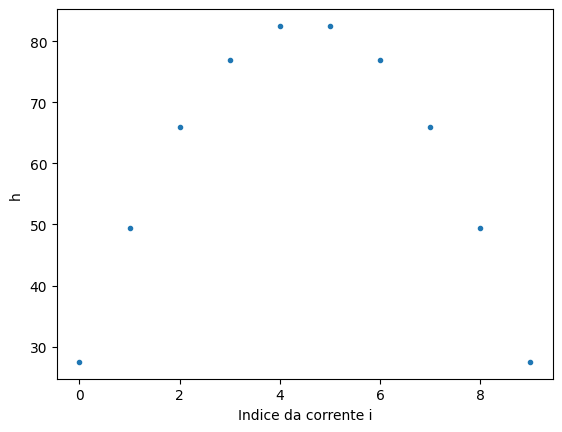

In [18]:
import numpy as np
import numpy.linalg as la
#import scipy.linalg as la
import matplotlib.pyplot as plt
#matriz retangular nao tem posto completo, ent nao daria para resolver um sist linear(se pa)

U = np.array ([
    [1,2,3],
    [4,5,6],
    [0,0,0]
])
print(la.matrix_rank(U))

A = np.array([[2,1,1],
              [2,0,2],
              [4,3,4]])
b = np.array([[-1],
              [1],
              [1]])
print(A)
print(b)

#Resolve o sist linear, x é o vetor de variaveis que estamos tentando encontrar
x = la.solve(A,b)
print(x)

# Erro numérico:
r = la.norm(A@x - b)
print(r)




N=10
R=20
V=110

b_ = np.full(N,V)
A_1 = np.diag(np.full(N,2*R))
A_2 = np.diag(np.full(N-1,-R),1)
print(A_1.shape)
print(A_2.shape)
A_ = A_1 +A_2 + A_2.T
print(A_)
i = la.solve(A_,b_)
print(i)
#Esse graf q ta tentando fazer seria da corrente i. Ficaria em formato de parabola =-ax² (o formato)
plt.plot(i,".")
plt.xlabel("Indice da corrente i")
plt.ylabel("h ")
plt.show()

Mudança de Base



Sejam duas bases B e C em um espaço vetorial. Queremos encontrar a matriz [A]ᶜᴮ que transforma as coordenadas de um vetor na base C para as coordenadas na base B.

[v]ᴮ = [A]ᶜᴮ [v]ᶜ

Para construir essa matriz, precisamos expressar cada vetor da base C como uma combinação linear dos vetores da base B. Cada uma dessas combinações lineares é um sistema linear a ser resolvido.

In [19]:
#x = a1*b_1+ a_2*b_2 + ... + a_n*b_n (na base b)
#x = d1*c1+d2*c2+ ... + dn*cn (na base c)
#a = [a1,a2,...,an] ->x na base B
#d = [d1,d2,...,dn] ->x na base C


In [20]:
#[b1]c = x_11 * c1+ x12* c2+ ... + x_1n*cn
#[b1]c = c*x_1

#Esse vetor b tem os elementos de b1 a bn e ele seria formado por x11*c, onde de é um vetor e x11 compoem elem da matriz na linha 1
#b1 seria referente a linha 1 da matriz x, ent multiplicaria cada elemento da linha 1 de x por cada elem do vetor c.
#X é o vetor (alguma porra) na base b, eu acho
#c parece q é uma matriz de coef e oq muda seria só a matriz b, para chegar em algum y
#acho as coord na base B na base C e dps subtitui na eq da expressao linear e dps junta tds c1 com o coef e chega em uma expressao q é basicamente
#[a1..an]* [x11...xn1]T(ta em col) + [a1..an]*[x12...xn2], seria x agrupado em uma matriz
#a matriz q muda de base b para C é a matriz mudança de base

#Exerc - pega lista de vetor c e criar uma matriz e para cada col resolve o sist cx+b e armaze e dps pega e..........

In [21]:
b = np.array([
    [1, 0, 0], # Vetor da base B
    [0, 1, 0], # Vetor da base B
    [0, 0, 1]  # Vetor da base B
]).T # Transposto para que cada coluna seja um vetor da base B

c = np.array([
    [1, 2, 3], # Vetor da base C
    [4, 5, 6], # Vetor da base C
    [2, 3, 7]  # Vetor da base C
]).T # Transposto para que cada coluna seja um vetor da base C
#Mudança de base é uma função bijetora - toda mtriz mudança de base é inversível
# A matriz de mudança da base C para a base B é encontrada resolvendo o sistema linear
# B * [coords_em_B] = [vetor_em_C] para cada vetor da base C.
# Isso é equivalente a resolver [coords_em_B] = inv(B) * [vetor_em_C]
# No entanto, é mais eficiente usar la.solve para cada vetor da base C.
# A matriz de mudança de base terá as coordenadas de cada vetor de C na base B como colunas.

# A matriz de mudança de base da base C para a base B, denotada [Id]_B^C,
# tem como colunas as coordenadas dos vetores da base C expressas na base B.
# Para encontrar as coordenadas do primeiro vetor de C ([1, 4, 2]) na base B, resolvemos:
# B * [x1, y1, z1].T = [1, 4, 2].T
# Onde [x1, y1, z1].T são as coordenadas na base B.
# Fazemos isso para cada vetor da base C.

# A matriz de mudança de base [Id]_B^C é a solução de B * [Id]_B^C = C
# Podemos resolver isso diretamente usando la.solve(B, C)
#matriz singular é uma matriz quadrada cujo determinante é zero. Matrizes singulares não possuem inversa,
#têm rank menor que seu número de linhas e resultam em sistemas lineares que podem não ter solução ou ter infinitas soluções.
try:
    matriz_mudanca_base = la.solve(b, c)
    print("Matriz de Mudança da Base C para a Base B:")
    print(matriz_mudanca_base)
except la.LinAlgError as e:
    print(f"Erro ao resolver o sistema linear: {e}")
    print("Verifique se a matriz da base (primeiro argumento em la.solve) é quadrada e não singular.")

# Exemplo de uso: Transformar um vetor v na base C para a base B
v_c = np.array([1, 1, 1]) # Um vetor v com coordenadas [1, 1, 1] na base C

# As coordenadas de v na base B são: [v]_B = [Id]_B^C * [v]_C
if 'matriz_mudanca_base' in locals():
    v_b = matriz_mudanca_base @ v_c
    print(f"\nVetor [1, 1, 1] na base C, expresso na base B:")
    print(v_b)
#A função np.vstack() da biblioteca NumPy empilha arrays verticalmente (linha por linha).
#Ela pega uma tupla ou lista de arrays como entrada e os concatena ao longo do eixo vertical.

def mud_base(B,C):
  C_mat= np.vstack(C).T
  x = []
  for b_i in B:
    x_i = la.solve(c,b_i)
    x.append(x_i)

  x = np.vstack(x).T
  return X

Matriz de Mudança da Base C para a Base B:
[[1. 4. 2.]
 [2. 5. 3.]
 [3. 6. 7.]]

Vetor [1, 1, 1] na base C, expresso na base B:
[ 7. 10. 16.]


In [22]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import networkx as nx
#sympy tenta pegar results numericos e joga para simbolos (se pa)



A = np.array([
    [1,1,0],
    [1,1,1],
    [0,1,1]
])

A_sym = sp.Matrix(A)
print(A_sym)
# Polynomio caracteristico
poli_caract = A_sym.charpoly()
print(poli_caract)
# Auto valores e auto vetores
auto_vec = A_sym.eigenvects()
auto_val = A_sym.eigenvals()
print(auto_val)
print("===========================")
print(auto_vec)

Matrix([[1, 1, 0], [1, 1, 1], [0, 1, 1]])
PurePoly(lambda**3 - 3*lambda**2 + lambda + 1, lambda, domain='ZZ')
{1: 1, 1 - sqrt(2): 1, 1 + sqrt(2): 1}
[(1, 1, [Matrix([
[-1],
[ 0],
[ 1]])]), (1 - sqrt(2), 1, [Matrix([
[       1],
[-sqrt(2)],
[       1]])]), (1 + sqrt(2), 1, [Matrix([
[      1],
[sqrt(2)],
[      1]])])]


In [23]:
#Como criar polinomios com numpy
#lambda**3 - 3*lambda**2 + lambda + 1, lambda
poly_car = np.array([1,-3,1,1])
auto_val = np.roots(poly_car)
print(auto_val)
print("=====")
auto_val, auto_vec = np.linalg.eig(A)
print(auto_val)
print("=====")
print(auto_vec)
print("=====")
auto_val = np.real(auto_val)
auto_val_im = np.imag(auto_val)
print(auto_val_im)
print("=====")

print(auto_val)
print("=====")

[ 2.41421356  1.         -0.41421356]
=====
[-0.41421356  1.          2.41421356]
=====
[[ 5.00000000e-01  7.07106781e-01  5.00000000e-01]
 [-7.07106781e-01  4.91354351e-16  7.07106781e-01]
 [ 5.00000000e-01 -7.07106781e-01  5.00000000e-01]]
=====
[0. 0. 0.]
=====
[-0.41421356  1.          2.41421356]
=====


In [24]:
import numpy as np
import matplotlib.pyplot as plt

"""
Aplicação: Algoritmo PageRank (Google)
"""
# Matriz de adjacência (quem aponta para quem)
# Páginas: A, B, C, D, E
paginas = ['A', 'B', 'C', 'D', 'E']
n_paginas = len(paginas)

# Links: A->B,C; B->C; C->A,B; D->B,C,E; E->A,D
adjacencia = np.array([
    [0, 1, 1, 0, 0],  # A aponta para B, C
    [0, 0, 1, 0, 0],  # B aponta para C
    [1, 1, 0, 0, 0],  # C aponta para A, B
    [0, 1, 1, 0, 1],  # D aponta para B, C, E
    [1, 0, 0, 1, 0]   # E aponta para A, D
])


print("Matriz de adjacência:")
print("   ", " ".join(paginas))
for i, pagina in enumerate(paginas):
    print(f"{pagina}: {adjacencia[i]}")

# Construir matriz de transição (Google Matrix)
# Normalizar por linha (probabilidade de seguir cada link)
soma_links = np.sum(adjacencia, axis=1)

# Tratar páginas sem links de saída (dangling nodes)
for i in range(n_paginas):
    if soma_links[i] == 0:
        adjacencia[i] = 1  # Aponta para todas as páginas igualmente
        soma_links[i] = n_paginas

# Matriz de transição estocástica
M = adjacencia / soma_links[:, np.newaxis]

print(f"\nMatriz de transição M:")
print(M)

# Adicionar fator de amortecimento (damping factor)
d = 0.85  # Probabilidade de seguir um link
# (1-d)/n: Probabilidade de pular para qualquer página aleatoriamente



G = d * M + (1 - d) / n_paginas * np.ones((n_paginas, n_paginas))

print(f"\nGoogle Matrix G (com damping factor d={d}):")
print(G)



Matriz de adjacência:
    A B C D E
A: [0 1 1 0 0]
B: [0 0 1 0 0]
C: [1 1 0 0 0]
D: [0 1 1 0 1]
E: [1 0 0 1 0]

Matriz de transição M:
[[0.         0.5        0.5        0.         0.        ]
 [0.         0.         1.         0.         0.        ]
 [0.5        0.5        0.         0.         0.        ]
 [0.         0.33333333 0.33333333 0.         0.33333333]
 [0.5        0.         0.         0.5        0.        ]]

Google Matrix G (com damping factor d=0.85):
[[0.03       0.455      0.455      0.03       0.03      ]
 [0.03       0.03       0.88       0.03       0.03      ]
 [0.455      0.455      0.03       0.03       0.03      ]
 [0.03       0.31333333 0.31333333 0.03       0.31333333]
 [0.455      0.03       0.03       0.455      0.03      ]]


In [25]:
Mautovet = np.array([
    [-2,0,0,0],
    [0,-2,0,0],
    [24,-12,2,0],
    [0,0,0,2]
])
#Os vetores de M formam uma Base?
rankM = np.linalg.matrix_rank(Mautovet)
if(rankM == Mautovet.shape[0]):
  print("Formam uma base")
else :
  print("Não formam uma base")


autoval,autovet = np.linalg.eig(Mautovet.T)
D = autoval
P=autovet

Mautovet_diag = P @ np.diag(D) @la.inv(P)
print("Matriz diagonalizada")
print(Mautovet_diag.real)

Formam uma base
Matriz diagonalizada
[[ -2.   0.  24.   0.]
 [  0.  -2. -12.   0.]
 [  0.   0.   2.   0.]
 [  0.   0.   0.   2.]]


*Teorema*: A aproximação ótima de posto $r$ de uma matriz $A \in \mathbb{R}$, no sentido de _minimos quadrados_ é dada pelo truncamento da decomposição SVD:

$$
\argmin_{\tilde{X},\ \text{s.a: rank}(\tilde{X})=r} \|X - \tilde{X}\|_{F} = \tilde{U}\tilde{\Sigma}\tilde{V}^*
$$

onde $\tilde{U}$ e $\tilde{V}$ representam as primeiras $r$ colunas de $U$ e $V$ e $\tilde{\Sigma}$ representa o bloco $r \times r$ da matriz $\Sigma$

In [26]:
import numpy as np
import matplotlib.pyplot as plt


img = plt.imread('kitten.jpg')
print(img.dtype, img.shape)
img = np.float64(img)
print(img.dtype)
plt.imshow(img, cmap='rainbow')

FileNotFoundError: [Errno 2] No such file or directory: 'kitten.jpg'

In [ ]:
# APLICAR SVD
U, S, Vt = np.linalg.svd(img, full_matrices=True)
print(U.shape, S.shape, Vt.shape)

A_reconst = U @ np.diag(S) @ Vt
print(A_reconst.shape)
plt.imshow(A_reconst, cmap='rainbow')

In [27]:
## SELECIONAR O POSTO DA MATRIX E COMPARAR COM O ORIGINAL
r = 50

Ur = U[:, :r] #pega todas as linhas das primeiras r colunas
Sr = np.diag(S[:r])
Vtr = Vt[:r, :] # pega as primeiras r linhas de tds colunas

A_r = Ur @ Sr @ Vtr
print(A_r.shape)
plt.imshow(A_r, cmap='rainbow')


tam_orig = 256**2
tam_r = 256*r + r + 256*r
print(tam_orig, tam_r)



NameError: name 'S' is not defined

In [28]:
## MOSTRAR VALORES SINGULARES
plt.plot(S)
plt.yscale('log')
plt.show()

NameError: name 'S' is not defined

In [29]:
## ACUMULO DE ENERGIA
#energia seria tipo a informação da matriz, os valores singulares representao infos da matriz
S2 = S**2
energia = np.cumsum(S2) / np.sum(S2)
plt.plot(energia)
plt.show()

NameError: name 'S' is not defined

## Quantificação do erro

$$
\|X - \tilde{X}\|^2_F = \sum_{i=r+1}^{n} \sigma_i^2
$$

In [30]:
# ERRO DA APROXIMAÇÃO
erro = np.cumsum(S2[::-1])[::-1] #pegando os elementos na ordem inversa S[::-1]
erro = np.sqrt(erro)
erro_relativo = erro / np.linalg.norm(img)
plt.plot(erro_relativo)
plt.yscale('log')
plt.show()

NameError: name 'S2' is not defined

In [31]:
# ERRO ATRAVÉS DOS VALORES SINGULARES
erro_real = np.linalg.norm(img - A_r)
print(erro_real)
print(erro[r])

NameError: name 'img' is not defined

## Exercício: Implementação Básica do SVD

**Objetivo:** Familiarizar-se com a função `np.linalg.svd()` e verificar as propriedades básicas da decomposição.

**Enunciado:**
Crie uma função `analisar_svd(matriz)` que:
1. Receba uma matriz A como entrada
2. Calcule a decomposição SVD: A = U × Σ × V^T
3. Imprima as dimensões de U, Σ e V^T
4. Verifique se a reconstrução A_reconstruída = U @ np.diag(s) @ Vt é igual à matriz original (use `np.allclose()`)
5. Retorne o número de valores singulares não-nulos (posto da matriz)

**Teste sua função com:**
- Uma matriz 4×3 aleatória
- Uma matriz identidade 5×5
- Uma matriz 50×50 de posto 2 (crie multiplicando duas matrizes de dimensões apropriadas)

In [32]:
import numpy as np
import numpy.linalg as la # Importado para la.solve

def analisar_svd(matriz):
  U, S, Vt = np.linalg.svd(matriz, full_matrices=True)
  print(f"Dimensões de U, S, Vt: {U.shape}, {S.shape}, {Vt.shape}")

  # Ajustar a matriz diagonal de S para a reconstrução
  # Cria uma matriz de zeros com as dimensões corretas e preenche a diagonal com S
  Sigma = np.zeros((matriz.shape[0], matriz.shape[1]))
  # A diagonal principal de Sigma deve ser preenchida com os valores singulares
  min_dim = min(matriz.shape[0], matriz.shape[1])
  Sigma[:min_dim, :min_dim] = np.diag(S)


  A_reconstruida = U @ Sigma @ Vt

  if(np.allclose(A_reconstruida, matriz)):
    print("A reconstrução é igual à matriz original")
  else:
    print("A reconstrução é diferente da matriz original")

  # O posto da matriz é o número de valores singulares não nulos
  # Usamos um limite de tolerância para considerar valores próximos de zero como zero
  posto = np.sum(S > 1e-10)
  return posto

A = np.array([
    [1,2,3],
    [4,5,6],
    [7,8,9]
])
postoA = analisar_svd(A)
print(f"Posto da matriz A: {postoA}")
print("\n")

B = np.eye(5)
postoB = analisar_svd(B)
print(f"Posto da matriz B: {postoB}")
print("\n")


# Cria duas matrizes com dimensões que resultarão em um posto máximo de 2 quando multiplicadas
matriz1 = np.random.rand(50, 2)
matriz2 = np.random.rand(2, 50)
# Multiplica as matrizes para obter uma matriz 50x50 com posto 2
matriz_posto_2 = matriz1 @ matriz2
postoM5050 = analisar_svd(matriz_posto_2)
print(f"Posto da matriz 50x50 (posto 2): {postoM5050}")
print("\n")

D = np.random.rand(4,3)
postoD = analisar_svd(D)
print(f"Posto da matriz D (4x3): {postoD}")

Dimensões de U, S, Vt: (3, 3), (3,), (3, 3)
A reconstrução é igual à matriz original
Posto da matriz A: 2


Dimensões de U, S, Vt: (5, 5), (5,), (5, 5)
A reconstrução é igual à matriz original
Posto da matriz B: 5


Dimensões de U, S, Vt: (50, 50), (50,), (50, 50)
A reconstrução é igual à matriz original
Posto da matriz 50x50 (posto 2): 2


Dimensões de U, S, Vt: (4, 4), (3,), (3, 3)
A reconstrução é igual à matriz original
Posto da matriz D (4x3): 3


In [33]:
import numpy as np

# Cria duas matrizes com dimensões que resultarão em um posto máximo de 2 quando multiplicadas
matriz1 = np.random.rand(50, 2)
matriz2 = np.random.rand(2, 50)

# Multiplica as matrizes para obter uma matriz 50x50 com posto 2
matriz_posto_2 = matriz1 @ matriz2

# Verifica o posto da matriz resultante
posto_resultante = np.linalg.matrix_rank(matriz_posto_2)

print(f"Dimensões da matriz resultante: {matriz_posto_2.shape}")
print(f"Posto da matriz resultante: {posto_resultante}")

Dimensões da matriz resultante: (50, 50)
Posto da matriz resultante: 2


### Verificação direta que $\hat{x}$ é solução

Para todo $x \neq \hat{x}$, vamos mostrar que $\|A\hat{x} -b\|^2 <\  $\|A\x -b\|^2$

__Lembrete__: $ \| u + v|\^2 = (u+v)^T(u+v) = \|u\|^2 + \|v\|^2 + 2 u^Tv$.

Temos:
$$
\begin{align*}
\|Ax-b\|^2 &= \|Ax\  {\color{cyan}- A\hat{x} + A\hat{x}} - b\|^2 \\
&=\|Ax - A\hat{x}\|^2 + \| A\hat{x} - b\|^2 + 2\  \color{yellow}{(Ax - A\hat{x})^T( A\hat{x} - b)}.
\end{align*}
$$

Observe que:

$$
\begin{align*}
\color{yellow}{(Ax - A\hat{x})^T( A\hat{x} - b)} &= (x^TA^T - \hat{x}^TA^T)( A\hat{x} - b)\\
&=(x^T - \hat{x}^T)A^T( A\hat{x} - b)\\
&=(x - \hat{x})^TA^T( A\hat{x} - b)\\
&=(x - \hat{x})^T( A^TA\hat{x} - A^Tb)\\
&=(x - \hat{x})^T( A^TA\hat{x} - A^Tb)\\
&=(x - \hat{x})^T\mathbf{0}\\
&=0\\
\end{align*}
$$

Dessa forma:

$$
\begin{align*}
\|Ax-b\|^2 =\|A(x - \hat{x})\|^2 + \| A\hat{x} - b\|^2.
\end{align*}
$$

como $\|A(x - \hat{x})\|^2 > 0$, pois $A$ tem colunas linearmente independentes e $x - \hat{x} = 0 \iff x = \hat{x}$, temos:

$$
\begin{align*}
\|Ax-b\|^2 >  \| A\hat{x} - b\|^2.
\end{align*}
$$


In [43]:
#Implementando a solução
A = np.random.rand(10,3)
b = np.random.rand(10,1)
x = np.linalg.lstsq(A,b,rcond=0)
print(x)
#Para achar inversa resolve um sist linear pq sera mais preciso e mais rápido

def mmq_1(A,b):
  M = A.T@A
  y=A.T@b
  return np.linalg.solve(M,y)

x_1 = mmq_1(A,b)
print(x_1)
#a decomposição SVD forma matrizes q são ortonormais (inversa igual a transposta)

def mmq_svd(A,b):
  U,S,Vt = np.linalg.svd(A)
  iS = 1./S
  piA = Vt.T @ np.diag(iS) @ U.T
  x = piA @ b
  return x


def mmq_qr(A,b):
  Q,R = np.linalg.qr(A)
  y = Q.T@b
  x = np.linalg.solve(R,y)
  return x

#Em geral o metod qr vai acabar sendo o mais rápido quando puder ser usado

(array([[ 0.46317991],
       [-0.1487366 ],
       [ 0.23962423]]), array([0.2360848]), np.int32(3), array([3.21459217, 0.9316985 , 0.53622678]))
[[ 0.46317991]
 [-0.1487366 ]
 [ 0.23962423]]
